<a href="https://colab.research.google.com/github/SarveshMD/colab-notebooks/blob/main/wisconsin_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [230]:
import kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import Module
from sklearn.preprocessing import StandardScaler

In [232]:
import copy

In [233]:
df = pd.read_csv(path + "/data.csv")

In [234]:
drop_cols = ["id"]
df = df.drop(drop_cols, axis=1)
df = df.dropna(axis=1)
df.head(), df.shape

(  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
 0         M        17.99         10.38          122.80     1001.0   
 1         M        20.57         17.77          132.90     1326.0   
 2         M        19.69         21.25          130.00     1203.0   
 3         M        11.42         20.38           77.58      386.1   
 4         M        20.29         14.34          135.10     1297.0   
 
    smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
 0          0.11840           0.27760          0.3001              0.14710   
 1          0.08474           0.07864          0.0869              0.07017   
 2          0.10960           0.15990          0.1974              0.12790   
 3          0.14250           0.28390          0.2414              0.10520   
 4          0.10030           0.13280          0.1980              0.10430   
 
    symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
 0         0.2419  ...         25.38

In [235]:
perm = torch.randperm(df.shape[0])

In [236]:
df = df.iloc[perm].reset_index(drop=True)
X_full = df.drop("diagnosis", axis=1)
print(X_full.head())
y_full = df["diagnosis"]
y_full = y_full.map({"M": 1, "B": 0})
train_size = int(X_full.shape[0]*0.8)
X_train, X_test = X_full[:train_size], X_full[train_size:]
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train, y_test = y_full[:train_size], y_full[train_size:]
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)
print(X_full.shape, y_full.shape)

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        13.87         16.21           88.52      593.7          0.08743   
1        13.94         13.17           90.31      594.2          0.12480   
2        15.19         13.21           97.65      711.8          0.07963   
3        14.64         15.24           95.77      651.9          0.11320   
4        13.54         14.36           87.46      566.3          0.09779   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.05492         0.01502              0.02088         0.1424   
1           0.09755         0.10100              0.06615         0.1976   
2           0.06934         0.03393              0.02657         0.1721   
3           0.13390         0.09966              0.07064         0.2116   
4           0.08129         0.06664              0.04781         0.1885   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

In [237]:
class CancerClassificationModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(in_features=30, out_features=16),
        nn.ReLU(),

        nn.Linear(in_features=16, out_features=8),
        nn.ReLU(),

        nn.Linear(in_features=8, out_features=1)
    )

  def forward(self, x):
    return self.network(x)

In [238]:
model = CancerClassificationModel()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01)

In [239]:
X_train.shape, y_train.shape

((455, 30), (455,))

In [240]:
X_train_tensor = torch.from_numpy(X_train).to(torch.float32)
y_train_tensor = torch.from_numpy(y_train.to_numpy()).to(torch.float32).view(-1, 1)
X_test_tensor = torch.from_numpy(X_test).to(torch.float32)
y_test_tensor = torch.from_numpy(y_test.to_numpy()).to(torch.float32).view(-1,1)

In [241]:
X_train_tensor.shape

torch.Size([455, 30])

In [242]:
epochs = 1000

epoch_count = []
train_loss_history = []
test_loss_history = []
best_state = None
best_test_loss = float("inf")

for epoch in range(epochs):
  model.train()
  optimizer.zero_grad()
  logits = model(X_train_tensor)
  loss = loss_fn(logits, y_train_tensor)
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test_tensor)
    test_loss = loss_fn(test_logits, y_test_tensor)

  if test_loss.item() < best_test_loss:
    best_state = copy.deepcopy(model.state_dict())
    best_test_loss = test_loss

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    train_loss_history.append(loss.item())
    test_loss_history.append(test_loss.item())

In [243]:
def plot_learning_curve(train_loss_history=train_loss_history, test_loss_history=test_loss_history, epoch_list=epoch_count):
  plt.figure(figsize=(7,4))
  plt.plot(epoch_list, train_loss_history, c="g", label="Training Loss")
  plt.plot(epoch_list, test_loss_history, c="b", label="Testing Loss")
  plt.legend()
  plt.xlabel("epoch")
  plt.ylabel("loss")
  plt.show()

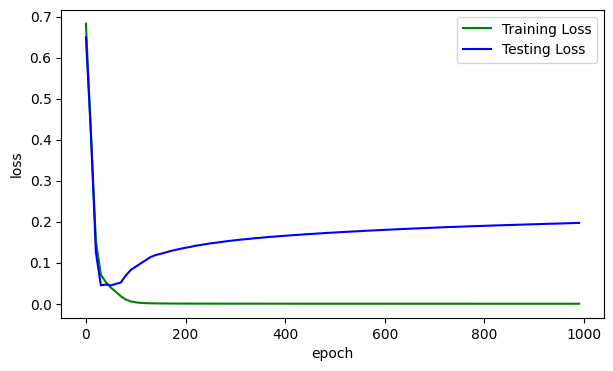

In [244]:
plot_learning_curve()

In [245]:
y_pred_logits = model(X_test_tensor).sigmoid()
preds = (y_pred_logits >= 0.5).int().squeeze().numpy()
y_test = y_test.to_numpy()
accuracy = sum(preds == y_test) / len(preds) * 100
print(accuracy)

97.36842105263158


In [246]:
loaded_model = CancerClassificationModel()
loaded_model.load_state_dict(best_state)
y_pred_logits = loaded_model(X_test_tensor).sigmoid()
preds = (y_pred_logits >= 0.5).int().squeeze().numpy()
accuracy = sum(preds == y_test) / len(preds) * 100
print(accuracy)

98.24561403508771
